In [ ]:
import pandas as pd


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import seaborn as sns

In [ ]:
df = pd.read_csv("netflix_titles.csv")

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
#Limpieza de datos
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df_limpio = df.copy()


In [ ]:
df_limpio["director"] = df_limpio["director"].fillna("Desconocido")
df_limpio["cast"] = df_limpio["cast"].fillna("Desconocido")
df_limpio["country"] = df_limpio["country"].fillna("Desconocido")
df_limpio["rating"] = df_limpio["rating"].fillna("Sin clasificación")
df_limpio["duration"] = df_limpio["duration"].fillna("No especificado")
df_limpio["date_added"] = df_limpio["date_added"].fillna("Fecha desconocida")

In [ ]:
print("Valores nulos después de limpieza:")

df_limpio.isnull().sum()

Valores nulos después de limpieza:


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
### Justificación de limpieza

#Se identificaron valores faltantes en columnas como director, reparto, país, fecha de agregado, clasificación y duración.
#No se eliminaron los registros porque representan contenido válido dentro de Netflix y eliminar demasiadas filas podría reducir la calidad del análisis.
#Por ello, se decidió reemplazar los valores faltantes con etiquetas como "Desconocido", "Sin clasificación" o "No especificado".
#También se verificó la existencia de registros duplicados para asegurar que el dataset no tuviera datos repetidos.

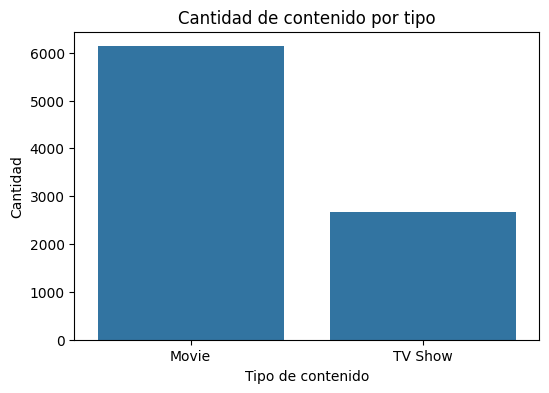

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_limpio, x="type")
plt.title("Cantidad de contenido por tipo")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
top_paises = df_limpio[df_limpio["country"] != "Desconocido"]["country"].value_counts().head(10)


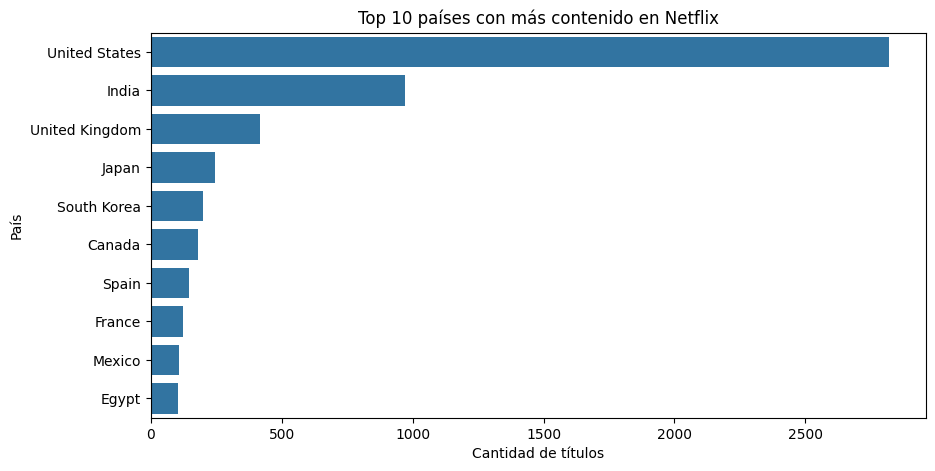

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_paises.values, y=top_paises.index)
plt.title("Top 10 países con más contenido en Netflix")
plt.xlabel("Cantidad de títulos")
plt.ylabel("País")
plt.show()

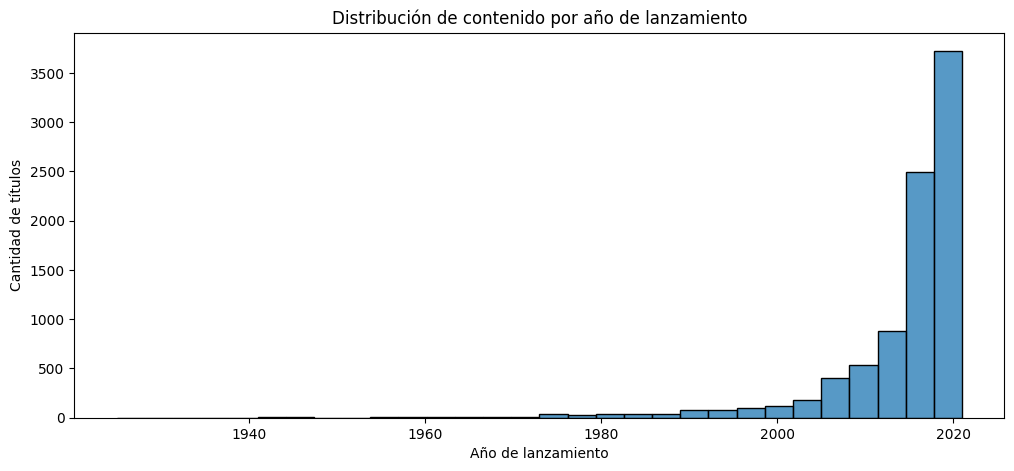

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(df_limpio["release_year"], bins=30)
plt.title("Distribución de contenido por año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Cantidad de títulos")
plt.show()

In [ ]:
top_rating = df_limpio["rating"].value_counts().head(10)


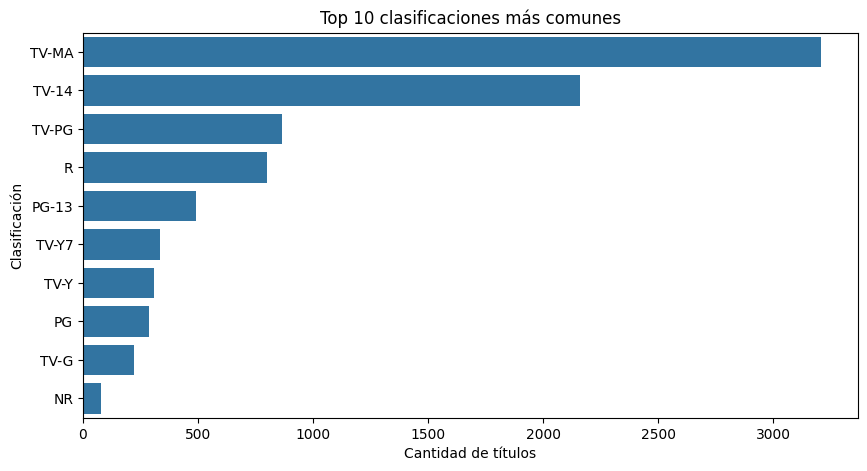

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_rating.values, y=top_rating.index)
plt.title("Top 10 clasificaciones más comunes")
plt.xlabel("Cantidad de títulos")
plt.ylabel("Clasificación")
plt.show()

In [ ]:
top_generos = df_limpio["listed_in"].value_counts().head(10)


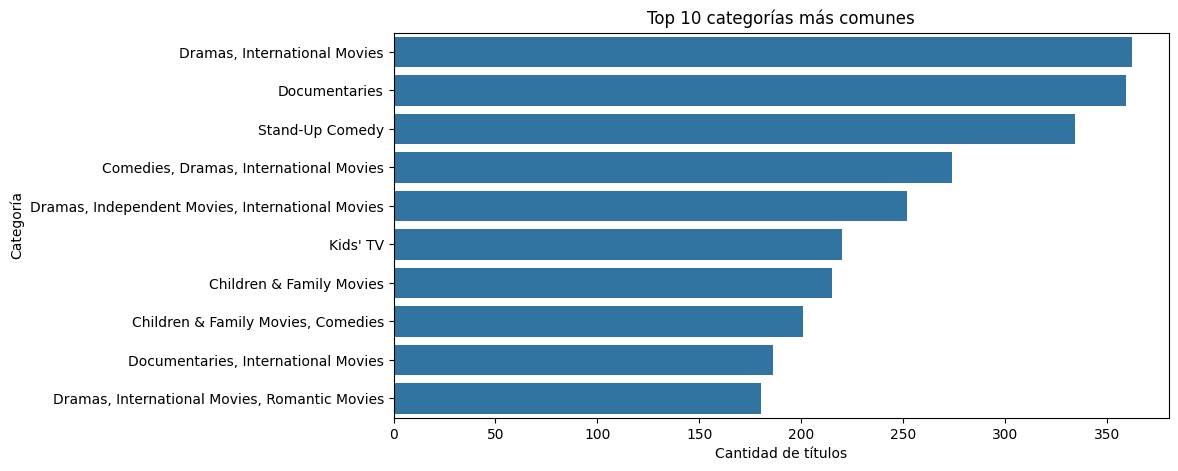

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_generos.values, y=top_generos.index)
plt.title("Top 10 categorías más comunes")
plt.xlabel("Cantidad de títulos")
plt.ylabel("Categoría")
plt.show()

In [ ]:
### Conclusiones del análisis

#1. El catálogo de Netflix contiene una mayor cantidad de películas que de series, lo que indica que la plataforma ha priorizado históricamente el contenido cinematográfico dentro de su biblioteca.

#2. Estados Unidos aparece como uno de los países con mayor presencia de contenido, lo cual refleja la fuerte influencia de la industria audiovisual estadounidense dentro de la plataforma.

#3. La mayor parte del contenido se concentra en años recientes, especialmente después del año 2010, lo que demuestra que Netflix mantiene un catálogo orientado a producciones modernas y actualizadas.

#4. Las clasificaciones más comunes muestran que gran parte del contenido está dirigido a públicos adolescentes y adultos, lo cual permite identificar el perfil general de audiencia de la plataforma.

#5. Las categorías más frecuentes ayudan a entender qué géneros predominan dentro del catálogo, permitiendo identificar tendencias de consumo y posibles preferencias de los usuarios.

In [ ]:
### Capa de Sabiduría

#A partir del análisis realizado, Netflix podría tomar mejores decisiones estratégicas sobre su catálogo.
#Por ejemplo, al identificar qué países, géneros y clasificaciones tienen mayor presencia, la plataforma puede decidir en qué tipo de contenido invertir más.
#También puede detectar oportunidades para ampliar contenido en regiones menos representadas o equilibrar mejor la oferta entre películas y series.

#Este análisis permite transformar datos simples en información útil, posteriormente en conocimiento sobre patrones del catálogo y finalmente en sabiduría para apoyar la toma de decisiones.